# Customer-Level Feature Engineering

## Purpose

The original Online Retail II dataset is recorded at the transaction-line level, where each row represents a product included in an invoice. However, Customer Lifetime Value analysis requires one observation per customer. Therefore, this notebook transforms the cleaned transaction data into a customer-level dataset containing historical behavioural features and future customer outcomes.

A strict chronological design was used to prevent data leakage. Transactions before 1 December 2010 were used to construct historical customer features, while transactions from 1 December 2010 onward were used to define future outcomes.

* Historical observation period: 1 December 2009 to 30 November 2010
* Future evaluation period: 1 December 2010 to 9 December 2011

Only information available during the historical observation period was used as input for the predictive models.

## Customer-Level Features

The following features were constructed for every customer observed during the historical period.

### Recency

Recency represents the number of days between the customer’s most recent historical purchase and the cutoff date:

$$
\text{Recency}_i
=
\text{Cutoff Date}
-
\text{Last Purchase Date}_i
$$

A smaller value indicates that the customer purchased more recently.

### Frequency

Frequency represents the number of distinct purchase invoices generated by the customer during the historical period:

$$
\text{Frequency}_i
=
\text{Number of Distinct Invoices}_i
$$

Invoices were counted rather than transaction lines because one invoice can contain multiple products.

### Monetary Value

Historical monetary value represents the customer’s total purchase revenue during the observation period:

$$
\text{Monetary Value}_i
=
\sum_j
\left(
\text{Quantity}_{ij}
\times
\text{Unit Price}_{ij}
\right)
$$

### Average and Maximum Order Value

Transaction lines belonging to the same invoice were first aggregated to obtain invoice-level revenue. Average order value represents the mean revenue per invoice, while maximum order value represents the customer’s largest historical order.

$$
\text{Average Order Value}_i
=
\frac{\text{Total Historical Revenue}_i}
{\text{Number of Orders}_i}
$$

### Purchase Quantity and Product Diversity

Total quantity represents the total number of product units purchased by a customer. Product diversity represents the number of distinct products purchased during the historical period.

### Customer Activity and Tenure

The following activity-related features were also created:

* First purchase date
* Last purchase date
* Customer tenure in days
* Number of active purchasing months
* Number of active purchasing days
* Average number of days between orders
* Standard deviation of days between orders

These features describe the duration, consistency and regularity of the customer relationship.

### Geographic Features

The most frequently recorded country was selected as each customer’s primary country. An additional binary variable, `IsUK`, was created to distinguish customers from the United Kingdom from customers in other countries.

### Return Behaviour

Historical return and cancellation behaviour was represented using:

* Number of return invoices
* Number of return transaction lines
* Total historical return value
* Return invoice rate

The return invoice rate was calculated as:

$$
\text{Return Invoice Rate}_i
=
\frac{\text{Return Invoices}_i}
{\text{Purchase Invoices}_i+\text{Return Invoices}_i}
$$

These variables may help determine whether previous return behaviour is associated with future customer retention or value.

## Future Outcomes

Future transactions were used only to construct the model targets.

### Repeat Purchase

A binary repeat-purchase variable was defined as:

$$
\text{Repeat Purchase}_i
=
\begin{cases}
1, & \text{if the customer purchased during the future period}\\
0, & \text{otherwise}
\end{cases}
$$

This variable will be used as the outcome of the logistic regression model.

### Future Purchase Count

Future purchase count represents the number of distinct invoices generated by the customer during the future period.

### Future Revenue

Future revenue represents the total positive purchase revenue generated by the customer during the future period:

$$
\text{Future Revenue}_i
=
\sum_j
\left(
\text{Future Quantity}_{ij}
\times
\text{Future Unit Price}_{ij}
\right)
$$

Customers without future purchases were assigned a future revenue of zero.

## Logarithmic Transformations

Several financial and behavioural variables were strongly right-skewed because a small number of wholesale customers generated exceptionally large purchases. These observations were not automatically removed because they may represent legitimate business customers.

The following transformation was applied where appropriate:

$$
X_{\log}=\ln(1+X)
$$

Log-transformed versions were created for frequency, monetary value, average order value, total quantity, product diversity and future revenue. The transformation reduces the influence of extreme observations while retaining the original customer records.

## Final Dataset

The resulting dataset contains one row per historical customer. Each row includes:

* Historical customer characteristics
* Purchasing-behaviour features
* Geographic information
* Return behaviour
* Future repeat-purchase status
* Future purchase count
* Future customer revenue

Customer IDs were verified to be unique and non-missing. This customer-level dataset will be used for descriptive analysis, statistical inference, repeat-purchase prediction, future-revenue modelling and revenue-based Customer Lifetime Value estimation.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_purchases = pd.read_csv(
    "/content/drive/MyDrive/Data/data/cleaned/online_retail_purchases.csv",
    parse_dates=["InvoiceDate"]
)

df_returns = pd.read_csv(
    "/content/drive/MyDrive/Data/data/cleaned/online_retail_returns.csv",
    parse_dates=["InvoiceDate"]
)

print("Purchases:", df_purchases.shape)
print("Returns:", df_returns.shape)

df_purchases.head()

Purchases: (779425, 13)
Returns: (18390, 13)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,SourcePeriod,IsCancellation,TransactionValue,IsReturn,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,2009-2010,False,83.4,False,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,2009-2010,False,81.0,False,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,2009-2010,False,81.0,False,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,2009-2010,False,100.8,False,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,2009-2010,False,30.0,False,30.0


In [6]:
print(df_purchases["InvoiceDate"].dtype)
print(df_returns["InvoiceDate"].dtype)

print(
    df_purchases["InvoiceDate"].min(),
    df_purchases["InvoiceDate"].max()
)

datetime64[ns]
datetime64[ns]
2009-12-01 07:45:00 2011-12-09 12:50:00


In [7]:
cutoff_date = pd.Timestamp("2010-12-01")

historical = df_purchases[
    df_purchases["InvoiceDate"] < cutoff_date
].copy()

future = df_purchases[
    df_purchases["InvoiceDate"] >= cutoff_date
].copy()

print("Historical period:")
print(
    historical["InvoiceDate"].min(),
    historical["InvoiceDate"].max()
)

print("\nFuture period:")
print(
    future["InvoiceDate"].min(),
    future["InvoiceDate"].max()
)

print("\nHistorical rows:", len(historical))
print("Future rows:", len(future))

Historical period:
2009-12-01 07:45:00 2010-11-30 19:35:00

Future period:
2010-12-01 08:26:00 2011-12-09 12:50:00

Historical rows: 386732
Future rows: 392693


In [8]:
historical_customers = (
    historical.groupby("CustomerID")
    .agg(
        LastPurchase=("InvoiceDate", "max"),
        Frequency=("InvoiceNo", "nunique"),
        MonetaryValue=("Revenue", "sum"),
        AverageTransactionValue=("Revenue", "mean"),
        TotalQuantity=("Quantity", "sum"),
        ProductDiversity=("StockCode", "nunique")
    )
    .reset_index()
)

historical_customers["RecencyDays"] = (
    cutoff_date - historical_customers["LastPurchase"]
).dt.days

historical_customers.head()

,CustomerID,LastPurchase,Frequency,MonetaryValue,AverageTransactionValue,TotalQuantity,ProductDiversity,RecencyDays
0,12346,2010-06-28 13:53:00,11,372.86,11.298788,70,26,155
1,12347,2010-10-31 14:20:00,1,611.53,15.288250,509,40,30
2,12348,2010-09-27 14:59:00,1,222.16,11.108000,373,20,64
3,12349,2010-10-28 08:23:00,3,2671.14,26.187647,993,90,33
4,12351,2010-11-29 15:23:00,1,300.93,14.330000,261,21,1


In [9]:
future_customers = (
    future.groupby("CustomerID")
    .agg(
        FuturePurchaseCount=("InvoiceNo", "nunique"),
        FutureRevenue=("Revenue", "sum")
    )
    .reset_index()
)

future_customers["RepeatPurchase"] = 1

future_customers.head()

,CustomerID,FuturePurchaseCount,FutureRevenue,RepeatPurchase
0,12346,1,77183.60,1
1,12347,7,4310.00,1
2,12348,4,1797.24,1
3,12349,1,1757.55,1
4,12350,1,334.40,1


In [10]:
customer_data = historical_customers.merge(
    future_customers,
    on="CustomerID",
    how="left"
)

columns_to_fill = [
    "FuturePurchaseCount",
    "FutureRevenue",
    "RepeatPurchase"
]

customer_data[columns_to_fill] = (
    customer_data[columns_to_fill]
    .fillna(0)
)

customer_data["RepeatPurchase"] = (
    customer_data["RepeatPurchase"]
    .astype(int)
)

customer_data.head()

,CustomerID,LastPurchase,Frequency,MonetaryValue,AverageTransactionValue,TotalQuantity,ProductDiversity,RecencyDays,FuturePurchaseCount,FutureRevenue,RepeatPurchase
0,12346,2010-06-28 13:53:00,11,372.86,11.298788,70,26,155,1.0,77183.60,1
1,12347,2010-10-31 14:20:00,1,611.53,15.288250,509,40,30,7.0,4310.00,1
2,12348,2010-09-27 14:59:00,1,222.16,11.108000,373,20,64,4.0,1797.24,1
3,12349,2010-10-28 08:23:00,3,2671.14,26.187647,993,90,33,1.0,1757.55,1
4,12351,2010-11-29 15:23:00,1,300.93,14.330000,261,21,1,0.0,0.00,0


In [11]:
print("Customer-level dataset shape:", customer_data.shape)

print(
    "\nDuplicate Customer IDs:",
    customer_data["CustomerID"].duplicated().sum()
)

print(
    "\nMissing Customer IDs:",
    customer_data["CustomerID"].isna().sum()
)

print("\nRepeat-purchase counts:")
print(customer_data["RepeatPurchase"].value_counts())

print("\nRepeat-purchase percentages:")
print(
    customer_data["RepeatPurchase"]
    .value_counts(normalize=True)
    .mul(100)
)

Customer-level dataset shape: (4266, 11)

Duplicate Customer IDs: 0

Missing Customer IDs: 0

Repeat-purchase counts:
RepeatPurchase
1    2726
0    1540
Name: count, dtype: int64

Repeat-purchase percentages:
RepeatPurchase
1    63.900609
0    36.099391
Name: proportion, dtype: float64


In [13]:
customer_data.to_csv(
    "/content/drive/MyDrive/Data/data/processed/customer_clv_model.csv",
    index=False
)

print("Customer-level dataset saved successfully.")

Customer-level dataset saved successfully.


In [14]:
historical_orders = (
    historical
    .groupby(["CustomerID", "InvoiceNo"], as_index=False)
    .agg(
        OrderDate=("InvoiceDate", "min"),
        OrderRevenue=("Revenue", "sum")
    )
)

order_features = (
    historical_orders
    .groupby("CustomerID")
    .agg(
        AverageOrderValue=("OrderRevenue", "mean"),
        MaximumOrderValue=("OrderRevenue", "max")
    )
    .reset_index()
)

customer_data = customer_data.drop(
    columns=["AverageTransactionValue"],
    errors="ignore"
)

customer_data = customer_data.merge(
    order_features,
    on="CustomerID",
    how="left"
)

customer_data.head()

,CustomerID,LastPurchase,Frequency,MonetaryValue,TotalQuantity,ProductDiversity,RecencyDays,FuturePurchaseCount,FutureRevenue,RepeatPurchase,AverageOrderValue,MaximumOrderValue
0,12346,2010-06-28 13:53:00,11,372.86,70,26,155,1.0,77183.60,1,33.896364,142.31
1,12347,2010-10-31 14:20:00,1,611.53,509,40,30,7.0,4310.00,1,611.530000,611.53
2,12348,2010-09-27 14:59:00,1,222.16,373,20,64,4.0,1797.24,1,222.160000,222.16
3,12349,2010-10-28 08:23:00,3,2671.14,993,90,33,1.0,1757.55,1,890.380000,1402.62
4,12351,2010-11-29 15:23:00,1,300.93,261,21,1,0.0,0.00,0,300.930000,300.93


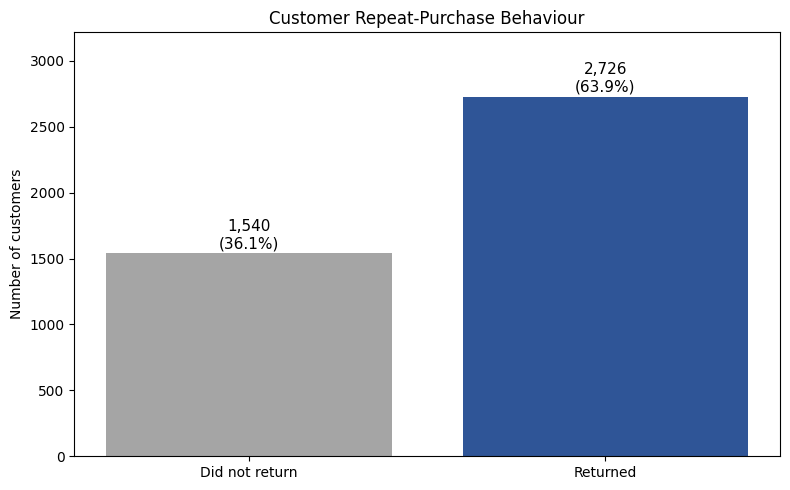

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

Path("/content/drive/MyDrive/Data/figures").mkdir(exist_ok=True)

repeat_counts = (
    customer_data["RepeatPurchase"]
    .value_counts()
    .sort_index()
)

labels = ["Did not return", "Returned"]
colors = ["#A5A5A5", "#2F5597"]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    labels,
    repeat_counts.values,
    color=colors
)

for bar, count in zip(bars, repeat_counts.values):
    percentage = count / repeat_counts.sum() * 100

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 40,
        f"{count:,}\n({percentage:.1f}%)",
        ha="center",
        fontsize=11
    )

plt.title("Customer Repeat-Purchase Behaviour")
plt.ylabel("Number of customers")
plt.ylim(0, repeat_counts.max() * 1.18)
plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Data/figures/03_repeat_purchase_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
customer_data.to_csv(
    "/content/drive/MyDrive/Data/data/processed/customer_clv_model.csv",
    index=False
)

In [17]:
customer_data[
    [
        "Frequency",
        "MonetaryValue",
        "AverageOrderValue",
        "RecencyDays",
        "TotalQuantity",
        "ProductDiversity",
        "FutureRevenue"
    ]
].describe().round(2)

,Frequency,MonetaryValue,AverageOrderValue,RecencyDays,TotalQuantity,ProductDiversity,FutureRevenue
count,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00
mean,4.32,1989.59,379.69,87.22,1256.90,62.64,1669.33
std,7.76,8599.15,506.28,95.11,6402.33,84.25,8590.55
min,1.00,2.95,2.95,0.00,1.00,1.00,0.00
25%,1.00,306.59,179.03,15.00,156.00,17.00,0.00
50%,2.00,681.81,288.21,47.00,378.00,38.00,314.88
75%,5.00,1662.22,424.01,134.00,973.75,78.00,1271.44
max,197.00,321329.74,11880.84,364.00,220600.00,1716.00,280206.02


In [18]:
import numpy as np

customer_data["LogFrequency"] = np.log1p(
    customer_data["Frequency"]
)

customer_data["LogMonetaryValue"] = np.log1p(
    customer_data["MonetaryValue"]
)

customer_data["LogAverageOrderValue"] = np.log1p(
    customer_data["AverageOrderValue"]
)

customer_data["LogTotalQuantity"] = np.log1p(
    customer_data["TotalQuantity"]
)

customer_data["LogProductDiversity"] = np.log1p(
    customer_data["ProductDiversity"]
)

customer_data["LogFutureRevenue"] = np.log1p(
    customer_data["FutureRevenue"]
)

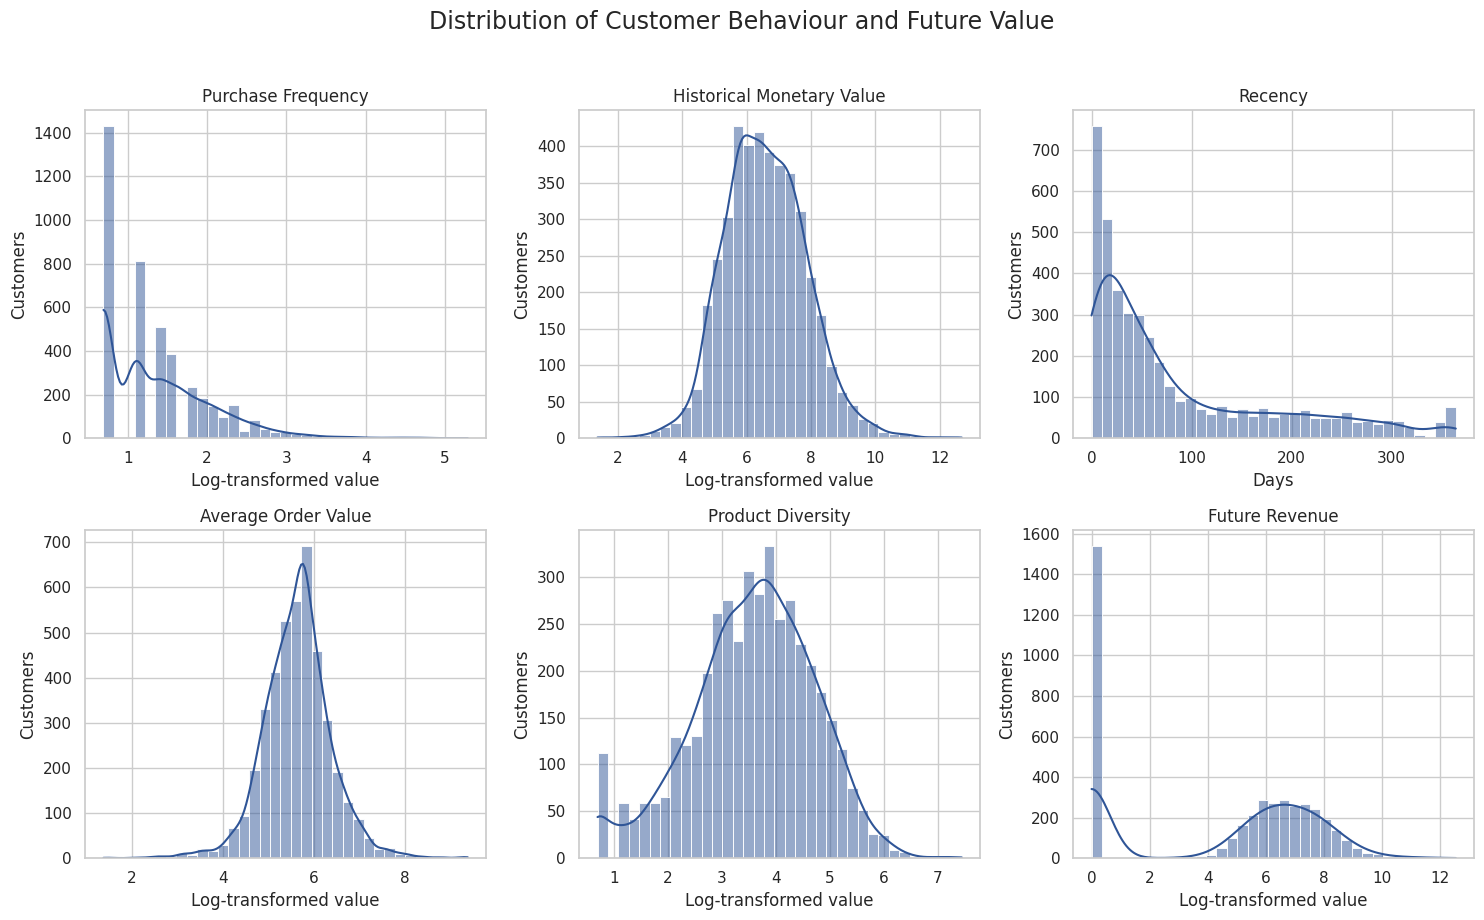

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

Path("/content/drive/MyDrive/Data/figures").mkdir(exist_ok=True)

sns.set_theme(style="whitegrid")

plot_variables = [
    ("LogFrequency", "Purchase Frequency"),
    ("LogMonetaryValue", "Historical Monetary Value"),
    ("RecencyDays", "Recency"),
    ("LogAverageOrderValue", "Average Order Value"),
    ("LogProductDiversity", "Product Diversity"),
    ("LogFutureRevenue", "Future Revenue")
]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9)
)

axes = axes.flatten()

for ax, (variable, title) in zip(axes, plot_variables):
    sns.histplot(
        customer_data[variable],
        bins=35,
        kde=True,
        color="#2F5597",
        ax=ax
    )

    ax.set_title(title)
    ax.set_ylabel("Customers")

    if variable.startswith("Log"):
        ax.set_xlabel("Log-transformed value")
    else:
        ax.set_xlabel("Days")

plt.suptitle(
    "Distribution of Customer Behaviour and Future Value",
    fontsize=17,
    y=1.02
)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Data/figures/04_customer_feature_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

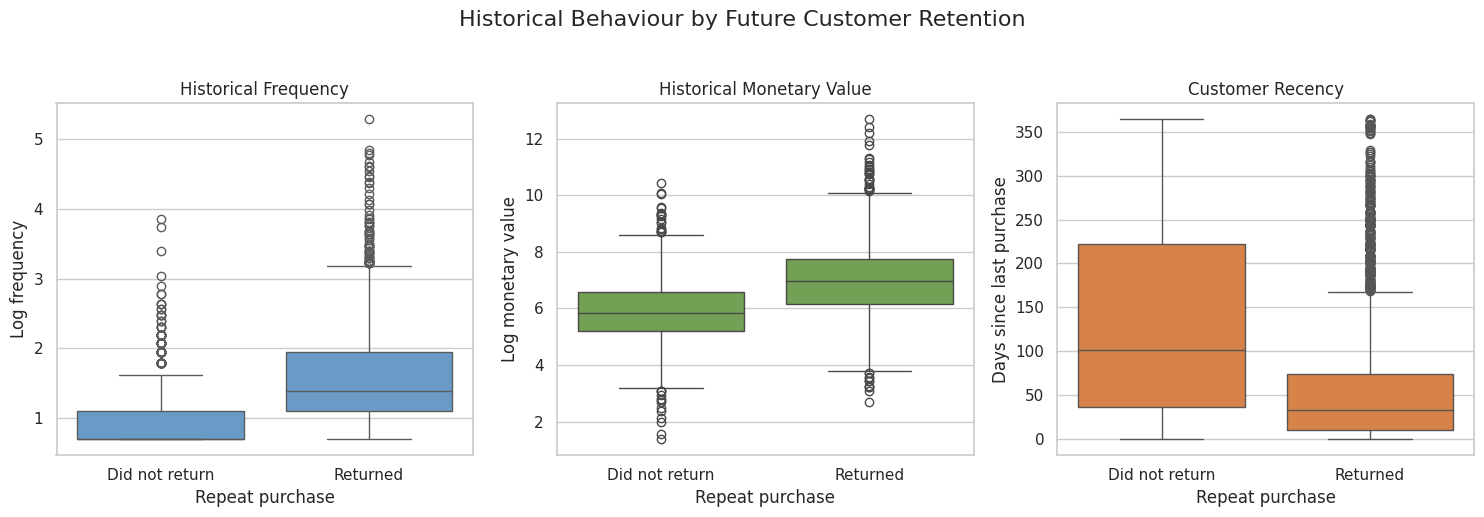

In [21]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

sns.boxplot(
    data=customer_data,
    x="RepeatPurchase",
    y="LogFrequency",
    color="#5B9BD5",
    ax=axes[0]
)

axes[0].set_title("Historical Frequency")
axes[0].set_xlabel("Repeat purchase")
axes[0].set_ylabel("Log frequency")

sns.boxplot(
    data=customer_data,
    x="RepeatPurchase",
    y="LogMonetaryValue",
    color="#70AD47",
    ax=axes[1]
)

axes[1].set_title("Historical Monetary Value")
axes[1].set_xlabel("Repeat purchase")
axes[1].set_ylabel("Log monetary value")

sns.boxplot(
    data=customer_data,
    x="RepeatPurchase",
    y="RecencyDays",
    color="#ED7D31",
    ax=axes[2]
)

axes[2].set_title("Customer Recency")
axes[2].set_xlabel("Repeat purchase")
axes[2].set_ylabel("Days since last purchase")

for ax in axes:
    ax.set_xticks([0, 1])
    ax.set_xticklabels([
        "Did not return",
        "Returned"
    ])

plt.suptitle(
    "Historical Behaviour by Future Customer Retention",
    fontsize=16,
    y=1.03
)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Data/figures/05_returning_customer_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
group_summary = (
    customer_data
    .groupby("RepeatPurchase")
    [
        [
            "Frequency",
            "MonetaryValue",
            "AverageOrderValue",
            "RecencyDays",
            "ProductDiversity"
        ]
    ]
    .median()
    .round(2)
)

group_summary.index = [
    "Did not return",
    "Returned"
]

group_summary

,Frequency,MonetaryValue,AverageOrderValue,RecencyDays,ProductDiversity
Did not return,1.0,346.53,231.16,102.0,22.0
Returned,3.0,1061.76,310.16,33.0,51.0


In [23]:
customer_data.to_csv(
    "/content/drive/MyDrive/Data/data/processed/customer_clv_model.csv",
    index=False
)

In [32]:
historical["PurchaseMonth"] = (
    historical["InvoiceDate"]
    .dt.to_period("M")
)

activity_features = (
    historical
    .groupby("CustomerID")
    .agg(
        FirstPurchase=("InvoiceDate", "min"),
        ActiveMonths=("PurchaseMonth", "nunique"),
        ActivePurchaseDays=(
            "InvoiceDate",
            lambda x: x.dt.date.nunique()
        )
    )
    .reset_index()
)

activity_features["CustomerTenureDays"] = (
    cutoff_date
    - activity_features["FirstPurchase"]
).dt.days

customer_data = customer_data.drop(
    columns=[
        "FirstPurchase",
        "ActiveMonths",
        "ActivePurchaseDays",
        "CustomerTenureDays"
    ],
    errors="ignore"
)

customer_data = customer_data.merge(
    activity_features,
    on="CustomerID",
    how="left",
    validate="one_to_one"
)

In [33]:
country_features = (
    historical
    .groupby("CustomerID")["Country"]
    .agg(lambda x: x.value_counts().index[0])
    .reset_index()
    .rename(
        columns={"Country": "PrimaryCountry"}
    )
)

country_features["IsUK"] = (
    country_features["PrimaryCountry"]
    == "United Kingdom"
).astype(int)

customer_data = customer_data.drop(
    columns=["PrimaryCountry", "IsUK"],
    errors="ignore"
)

customer_data = customer_data.merge(
    country_features,
    on="CustomerID",
    how="left",
    validate="one_to_one"
)

In [34]:
historical_returns = df_returns[
    df_returns["InvoiceDate"] < cutoff_date
].copy()

return_features = (
    historical_returns
    .groupby("CustomerID")
    .agg(
        ReturnInvoiceCount=("InvoiceNo", "nunique"),
        ReturnLineCount=("InvoiceNo", "size"),
        HistoricalReturnValue=("ReturnValue", "sum")
    )
    .reset_index()
)

customer_data = customer_data.drop(
    columns=[
        "ReturnInvoiceCount",
        "ReturnLineCount",
        "HistoricalReturnValue",
        "ReturnInvoiceRate"
    ],
    errors="ignore"
)

customer_data = customer_data.merge(
    return_features,
    on="CustomerID",
    how="left",
    validate="one_to_one"
)

return_columns = [
    "ReturnInvoiceCount",
    "ReturnLineCount",
    "HistoricalReturnValue"
]

customer_data[return_columns] = (
    customer_data[return_columns]
    .fillna(0)
)

customer_data["ReturnInvoiceRate"] = (
    customer_data["ReturnInvoiceCount"]
    /
    (
        customer_data["Frequency"]
        + customer_data["ReturnInvoiceCount"]
    )
)

In [35]:
order_intervals = historical_orders.sort_values(
    ["CustomerID", "OrderDate"]
).copy()

order_intervals["PreviousOrderDate"] = (
    order_intervals
    .groupby("CustomerID")["OrderDate"]
    .shift(1)
)

order_intervals["DaysBetweenOrders"] = (
    order_intervals["OrderDate"]
    - order_intervals["PreviousOrderDate"]
).dt.total_seconds() / 86400

In [36]:
interval_features = (
    order_intervals
    .groupby("CustomerID")
    .agg(
        AverageDaysBetweenOrders=(
            "DaysBetweenOrders",
            "mean"
        ),
        StdDaysBetweenOrders=(
            "DaysBetweenOrders",
            "std"
        )
    )
    .reset_index()
)

customer_data = customer_data.drop(
    columns=[
        "AverageDaysBetweenOrders",
        "StdDaysBetweenOrders"
    ],
    errors="ignore"
)

customer_data = customer_data.merge(
    interval_features,
    on="CustomerID",
    how="left",
    validate="one_to_one"
)

customer_data[
    [
        "AverageDaysBetweenOrders",
        "StdDaysBetweenOrders"
    ]
] = customer_data[
    [
        "AverageDaysBetweenOrders",
        "StdDaysBetweenOrders"
    ]
].fillna(0)

In [37]:
print("Final shape:", customer_data.shape)

print(
    "Duplicate Customer IDs:",
    customer_data["CustomerID"].duplicated().sum()
)

print(
    "Missing Customer IDs:",
    customer_data["CustomerID"].isna().sum()
)

print("\nMissing values:")
print(
    customer_data.isna()
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

Final shape: (4266, 30)
Duplicate Customer IDs: 0
Missing Customer IDs: 0

Missing values:
CustomerID             0
LastPurchase           0
Frequency              0
MonetaryValue          0
TotalQuantity          0
ProductDiversity       0
RecencyDays            0
FuturePurchaseCount    0
FutureRevenue          0
RepeatPurchase         0
dtype: int64


In [39]:
customer_data.to_csv(
    "/content/drive/MyDrive/Data/data/processed/customer_clv_model.csv",
    index=False
)

print("Feature engineering completed.")

Feature engineering completed.


In [41]:
import pandas as pd
import numpy as np

df_purchases = pd.read_csv(
    "/content/drive/MyDrive/Data/data/cleaned/online_retail_purchases.csv",
    parse_dates=["InvoiceDate"]
)

customer_data = pd.read_csv(
    "/content/drive/MyDrive/Data/data/processed/customer_clv_model.csv",
    parse_dates=["LastPurchase"]
)

In [42]:
df_purchases["CustomerID"] = (
    pd.to_numeric(
        df_purchases["CustomerID"],
        errors="coerce"
    )
    .astype("Int64")
    .astype("string")
)

customer_data["CustomerID"] = (
    pd.to_numeric(
        customer_data["CustomerID"],
        errors="coerce"
    )
    .astype("Int64")
    .astype("string")
)

In [43]:
cutoff_date = pd.Timestamp("2010-12-01")

historical = df_purchases[
    df_purchases["InvoiceDate"] < cutoff_date
].copy()

In [44]:
country_features = (
    historical
    .groupby("CustomerID")["Country"]
    .agg(
        lambda values:
        values.mode().iloc[0]
        if not values.mode().empty
        else np.nan
    )
    .reset_index()
    .rename(
        columns={"Country": "PrimaryCountry"}
    )
)

In [45]:
country_features["IsUK"] = (
    country_features["PrimaryCountry"]
    .eq("United Kingdom")
    .astype(int)
)

country_features.head()

,CustomerID,PrimaryCountry,IsUK
0,12346,United Kingdom,1
1,12347,Iceland,0
2,12348,Finland,0
3,12349,Italy,0
4,12351,Unspecified,0


In [46]:
customer_data = customer_data.drop(
    columns=["PrimaryCountry", "IsUK"],
    errors="ignore"
)

customer_data = customer_data.merge(
    country_features,
    on="CustomerID",
    how="left",
    validate="one_to_one"
)

In [47]:
print(
    customer_data[
        ["CustomerID", "PrimaryCountry", "IsUK"]
    ].head()
)

print("\nMissing countries:")
print(
    customer_data["PrimaryCountry"]
    .isna()
    .sum()
)

print("\nUK classification:")
print(
    customer_data["IsUK"]
    .value_counts(dropna=False)
)

  CustomerID  PrimaryCountry  IsUK
0      12346  United Kingdom     1
1      12347         Iceland     0
2      12348         Finland     0
3      12349           Italy     0
4      12351     Unspecified     0

Missing countries:
0

UK classification:
IsUK
1    3929
0     337
Name: count, dtype: int64


In [48]:
customer_data.to_csv(
    "/content/drive/MyDrive/Data/data/processed/customer_clv_model.csv",
    index=False
)

print("Updated customer dataset saved.")

Updated customer dataset saved.


In [49]:
assert "PrimaryCountry" in customer_data.columns
assert "IsUK" in customer_data.columns

print("Country features are available.")

Country features are available.
